<a href="https://colab.research.google.com/github/lara-ms/Curso_ML/blob/main/notebooks/regress%C3%A3o_log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão logística

In [1]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score, log_loss

## 1. Geração dos dados

In [ ]:
# Reset pseudo random generator to a known value so that results are reproducible.
seed = 42
# Reset the PN sequence generator.
np.random.seed(seed)

In [ ]:
# Number of examples.
N = 1000

# Create a 2-class dataset for classification.
# Factor: Scale factor between inner and outer circle.
X, y = make_circles(n_samples=N, factor=.5, noise=.05, random_state=seed)

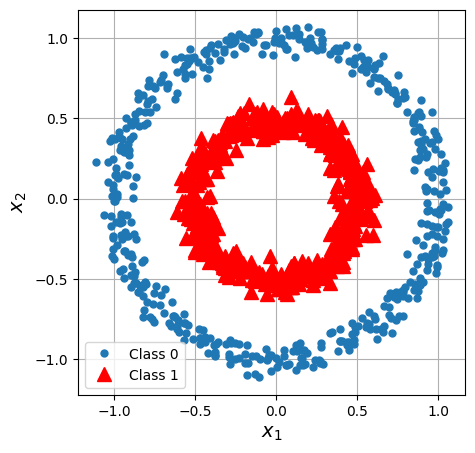

In [ ]:
# Plot the two circles.
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)
fig = plt.figure(figsize=(5,5))
plt.plot(X[idx0,0], X[idx0,1], '.', markersize=10, label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'r^', markersize=10, label='Class 1')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.legend()
plt.grid()
plt.show()

## 2. Divisão do dataset entre treino e teste

**OBS**.: 90% para treinamento e 10 para teste.

In [ ]:
# Divide o dataset em treinamento e teste
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.1, random_state=seed)

## 3. Validação cruzada: k-fold


Usaremos a métrica conhecida como acurácia para escolher o melhor modelo.

A **acurácia** é uma métrica que mede **a proporção de previsões corretas feitas por um modelo** em relação ao total de previsões realizadas.

#### Definição formal

$
\text{Acurácia}=\frac{\text{número de previsões corretas}}{\text{número total de amostras}}
$

Portanto, diferentemente do EMQ, quanto maior o valor da acurácia, melhor o desempenho do classificador.

Assim, queremos encontrar o modelo que **maximize a acurácia**.

In [ ]:
# Ordem de polinômios de 1 a 10
degrees = list(range(1, 31))

train_acc = []
val_acc = []

train_loss = []
val_loss = []

# KFold
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=seed)

for deg in degrees:
    # armazenar acurácia média por fold
    fold_train_acc = []
    fold_val_acc = []

    # armazenar erro médio por fold
    fold_train_loss = []
    fold_val_loss = []

    for train_idx, val_idx in kf.split(X_train_full):
        X_train = X_train_full[train_idx]
        y_train = y_train_full[train_idx]
        X_val = X_train_full[val_idx]
        y_val = y_train_full[val_idx]

        # Pipeline: padronização + polinômio + regressor logístico
        model = make_pipeline(
            PolynomialFeatures(degree=deg, include_bias=False), # include_bias já é feito pelo LogisticRegression
            StandardScaler(),
            LogisticRegression(penalty=None, random_state=seed) # Regressor logístico: não penalizamos, pois queremos identificar modelos que se sobreajustam.
        )

        # Treinar
        model.fit(X_train, y_train)

        # Prever classes.
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Prever probabilidades.
        y_train_prob = model.predict_proba(X_train)
        y_val_prob = model.predict_proba(X_val)

        # Calcular acurácia
        fold_train_acc.append(accuracy_score(y_train, y_train_pred))
        fold_val_acc.append(accuracy_score(y_val, y_val_pred))

        # Calcular entropia cruzada.
        fold_train_loss.append(log_loss(y_train, y_train_prob))
        fold_val_loss.append(log_loss(y_val, y_val_prob))

    # Média das acurácias dos folds
    train_acc.append(np.mean(fold_train_acc))
    val_acc.append(np.mean(fold_val_acc))

    # Média dos erros dos folds
    train_loss.append(np.mean(fold_train_loss))
    val_loss.append(np.mean(fold_val_loss))

## 4. Apresentação dos resultados da validação cruzada

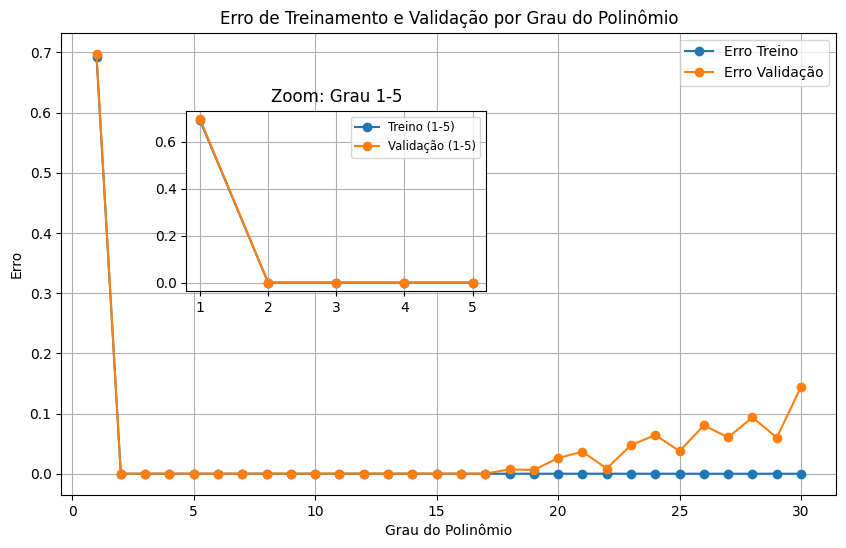

In [ ]:
# Plot do erro vs grau do polinômio
fig, ax_main = plt.subplots(figsize=(10, 6))

# gráfico principal (1 a 30)
ax_main.plot(degrees, train_loss, label='Erro Treino', marker='o')
ax_main.plot(degrees, val_loss, label='Erro Validação', marker='o')
ax_main.set_xlabel('Grau do Polinômio')
ax_main.set_ylabel('Erro')
ax_main.set_title('Erro de Treinamento e Validação por Grau do Polinômio')
ax_main.legend()
ax_main.grid(True)

# inset para ordens 1 a 5
left, bottom, width, height = [0.25, 0.45, 0.3, 0.3]  # posição na figura (relativo)
ax_inset = fig.add_axes([left, bottom, width, height])

# selecionar apenas indices 1 a 5
idx_small = [i for i, deg in enumerate(degrees) if deg <= 5]
small_deg = [degrees[i] for i in idx_small]
small_train_loss = [train_loss[i] for i in idx_small]
small_val_loss = [val_loss[i] for i in idx_small]

ax_inset.plot(small_deg, small_train_loss, label='Treino (1-5)', marker='o')
ax_inset.plot(small_deg, small_val_loss, label='Validação (1-5)', marker='o')
ax_inset.set_title('Zoom: Grau 1-5')
ax_inset.set_xticks(small_deg)
ax_inset.grid(True)
ax_inset.legend(fontsize='small')

plt.show()

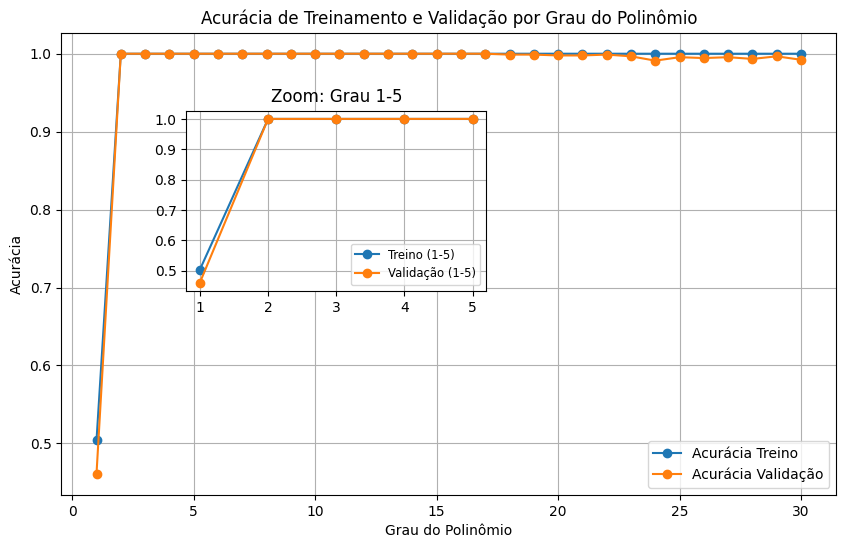

In [ ]:
# Plot do acurácia vs grau do polinômio
fig, ax_main = plt.subplots(figsize=(10, 6))

# gráfico principal (1 a 30)
ax_main.plot(degrees, train_acc, label='Acurácia Treino', marker='o')
ax_main.plot(degrees, val_acc, label='Acurácia Validação', marker='o')
ax_main.set_xlabel('Grau do Polinômio')
ax_main.set_ylabel('Acurácia')
ax_main.set_title('Acurácia de Treinamento e Validação por Grau do Polinômio')
ax_main.legend()
ax_main.grid(True)

# inset para ordens 1 a 5
left, bottom, width, height = [0.25, 0.45, 0.3, 0.3]  # posição na figura (relativo)
ax_inset = fig.add_axes([left, bottom, width, height])

# selecionar apenas indices 1 a 5
idx_small = [i for i, deg in enumerate(degrees) if deg <= 5]
small_deg = [degrees[i] for i in idx_small]
small_train_acc = [train_acc[i] for i in idx_small]
small_val_acc = [val_acc[i] for i in idx_small]

ax_inset.plot(small_deg, small_train_acc, label='Treino (1-5)', marker='o')
ax_inset.plot(small_deg, small_val_acc, label='Validação (1-5)', marker='o')
ax_inset.set_title('Zoom: Grau 1-5')
ax_inset.set_xticks(small_deg)
ax_inset.grid(True)
ax_inset.legend(fontsize='small')

plt.show()

## Pergunta: Se qualquer grau maior ou igual a 2 e menor do que 20 dá uma acurácia de 100%, qual grau devemos usar?

## 5. Melhor grau

In [ ]:
# Melhor grau
best_degree = degrees[np.argmax(val_acc)]
print(f"Melhor grau de polinômio segundo a validação: {best_degree}")

Melhor grau de polinômio segundo a validação: 2


## 6. Resultado final

In [ ]:
# Treinar esse melhor modelo com todo o conjunto de treino
best_model = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(),
    LogisticRegression(penalty=None, random_state=seed)
)
best_model.fit(X_train_full, y_train_full)

# Avaliar no conjunto de teste
y_test_pred = best_model.predict(X_test)
test_error = accuracy_score(y_test, y_test_pred)
print(f"Acurácia no conjunto de teste com grau {best_degree}: {test_error:.4f}")

Acurácia no conjunto de teste com grau 2: 1.0000


## 7. Regiões de decisão

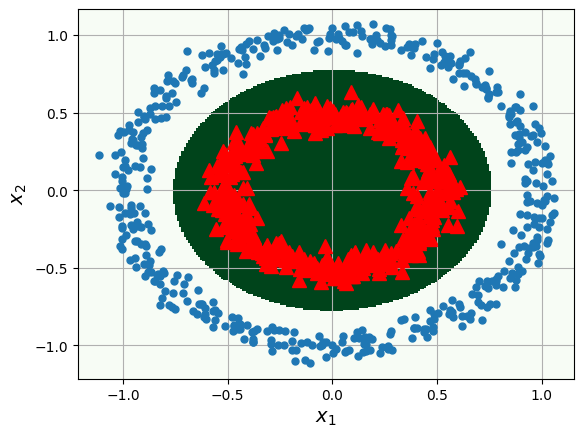

In [ ]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
h = .01  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# This attribute matrix must also follow the same shape
# as the one created for the training.
attribute_matrix = np.c_[xx.ravel(), yy.ravel()]

# Probabilities as output.
Z = best_model.predict(attribute_matrix)

# Put the result into a color plot.
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Greens, shading='auto')

# Plot also the training points.
plt.plot(X[idx0,0], X[idx0,1], '.', markersize=10, label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'r^', markersize=10, label='Class 1')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid()

plt.show()